# Intent–Behavior Deviation in Smart Contracts
## Notebook 2: Tier 2 — MLP Neural Network (3-Layer)
**Architecture:** 398 → 256 → 128 → 1 · BatchNorm · Dropout · Adam · Early Stopping  
**Epochs:** 20–100 (patience=10) · GPU T4 accelerated  
**Label:** `target` (0=safe, 1=rugpull)

In [1]:
import io, requests

# ─────────────────────────────────────────────────────────────────────────────
# Load dataset directly from GitHub (raw CSV)
# ─────────────────────────────────────────────────────────────────────────────
GITHUB_RAW_URL = (
    'https://raw.githubusercontent.com/AbrarBb/Intent-Behavior-Deviation-Dataset'
    '/main/ml_dataset_verified_full.csv'
)

print('Downloading dataset from GitHub...')
response = requests.get(GITHUB_RAW_URL)
response.raise_for_status()
CSV_PATH = io.StringIO(response.text)
print('✅ Dataset loaded successfully from GitHub')

✅ Dataset loaded successfully from GitHub


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, json, warnings
warnings.filterwarnings('ignore')
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics         import (f1_score, roc_auc_score, roc_curve,
                                      confusion_matrix, classification_report)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
plt.rcParams['figure.dpi']=120
COLORS=['#2ec7cc','#db70c0']
SEED=42; torch.manual_seed(SEED); np.random.seed(SEED)

Device: cuda


In [3]:
import os
try:
    assert os.path.exists('dataset_full.csv')
    df_full=pd.read_csv('dataset_full.csv')
    df_bal =pd.read_csv('dataset_balanced.csv')
    with open('col_info.json') as f: col_info=json.load(f)
    HYBRID_COLS=col_info['hybrid_cols']; LABEL_COL=col_info['label_col']
except:
    df_full=pd.read_csv(CSV_PATH)
    EMB_COLS=[c for c in df_full.columns if c.startswith('emb_')]
    BEHAV_COLS=['owner_withdraw','emergency_withdraw','unrestricted_mint',
                'regex_owner_withdraw','regex_emergency_withdraw','regex_unrestricted_mint',
                'slither_ok','slither_high_count','slither_arbitrary_send',
                'slither_suicidal','slither_unchecked_lowlevel',
                'slither_controlled_delegatecall','slither_delegatecall_loop',
                'slither_ownerish_any']
    HYBRID_COLS=EMB_COLS+BEHAV_COLS; LABEL_COL='target'
    min_c=df_full[LABEL_COL].value_counts().min()
    df_bal=pd.concat([df_full[df_full[LABEL_COL]==0].sample(min_c,random_state=SEED),
                       df_full[df_full[LABEL_COL]==1].sample(min_c,random_state=SEED)]).reset_index(drop=True)

INPUT_DIM=len(HYBRID_COLS)
scaler=StandardScaler()
X_full=scaler.fit_transform(df_full[HYBRID_COLS].values); y_full=df_full[LABEL_COL].values
X_bal =StandardScaler().fit_transform(df_bal[HYBRID_COLS].values);  y_bal =df_bal[LABEL_COL].values
print(f'Full:{X_full.shape} Balanced:{X_bal.shape} Features:{INPUT_DIM}')

Full:(3324, 398) Balanced:(2044, 398) Features:398


---
## MLP Architecture

In [4]:
class MLP3Layer(nn.Module):
    def __init__(self,input_dim,dropout=0.3):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128,1))
    def forward(self,x): return self.net(x).squeeze(1)

print(MLP3Layer(INPUT_DIM))

MLP3Layer(
  (net): Sequential(
    (0): Linear(in_features=398, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [5]:
def train_mlp(X_tr,y_tr,X_vl,y_vl,input_dim,dropout=0.3,lr=0.001,
               batch_size=64,max_epochs=100,patience=10,use_class_weight=True):
    if use_class_weight:
        pos_w=torch.tensor([(y_tr==0).sum()/(y_tr==1).sum()],dtype=torch.float32).to(device)
    else: pos_w=None
    model=MLP3Layer(input_dim,dropout).to(device)
    opt=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)
    sched=optim.lr_scheduler.ReduceLROnPlateau(opt,patience=5,factor=0.5)
    dl=DataLoader(TensorDataset(torch.tensor(X_tr,dtype=torch.float32),
                                 torch.tensor(y_tr,dtype=torch.float32)),
                  batch_size=batch_size,shuffle=True)
    Xvl_t=torch.tensor(X_vl,dtype=torch.float32).to(device)
    yvl_t=torch.tensor(y_vl,dtype=torch.float32).to(device)
    hist={'train_loss':[],'val_loss':[],'val_f1':[],'val_auc':[]}
    best_f1,best_st,wait=0,None,0
    for ep in range(max_epochs):
        model.train(); tl=0
        for xb,yb in dl:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
            loss=nn.functional.binary_cross_entropy_with_logits(
                model(xb),yb,pos_weight=pos_w) if pos_w is not None else \
                 nn.functional.binary_cross_entropy_with_logits(model(xb),yb)
            loss.backward(); opt.step(); tl+=loss.item()*len(xb)
        model.eval()
        with torch.no_grad():
            vl=model(Xvl_t)
            vl_loss=nn.functional.binary_cross_entropy_with_logits(
                vl,yvl_t,pos_weight=pos_w).item() if pos_w is not None else \
                nn.functional.binary_cross_entropy_with_logits(vl,yvl_t).item()
            vp=torch.sigmoid(vl).cpu().numpy()
            vf=f1_score(y_vl,(vp>0.5).astype(int),average='macro')
            va=roc_auc_score(y_vl,vp)
        hist['train_loss'].append(tl/len(X_tr)); hist['val_loss'].append(vl_loss)
        hist['val_f1'].append(vf); hist['val_auc'].append(va)
        sched.step(vl_loss)
        if vf>best_f1: best_f1=vf; best_st={k:v.clone() for k,v in model.state_dict().items()}; wait=0
        else:
            wait+=1
            if wait>=patience: break
    model.load_state_dict(best_st)
    return model,hist
print('Training function ready')

Training function ready


---
## 5-Fold CV — Full & Balanced

In [6]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
fold_f1_full,fold_auc_full,hists_full=[],[],[]
print('5-fold CV — FULL')
for fold,(tri,vli) in enumerate(cv.split(X_full,y_full)):
    m,h=train_mlp(X_full[tri],y_full[tri],X_full[vli],y_full[vli],INPUT_DIM)
    m.eval()
    with torch.no_grad():
        p=torch.sigmoid(m(torch.tensor(X_full[vli],dtype=torch.float32).to(device))).cpu().numpy()
    f=f1_score(y_full[vli],(p>0.5).astype(int),average='macro')
    a=roc_auc_score(y_full[vli],p)
    fold_f1_full.append(f); fold_auc_full.append(a); hists_full.append(h)
    print(f'  Fold {fold+1}: F1={f:.4f} AUC={a:.4f} Epochs={len(h["val_f1"])}')
print(f'FULL → F1:{np.mean(fold_f1_full):.4f}±{np.std(fold_f1_full):.4f}  AUC:{np.mean(fold_auc_full):.4f}')

5-fold CV — FULL
  Fold 1: F1=0.9840 AUC=0.9990 Epochs=26
  Fold 2: F1=0.9615 AUC=0.9937 Epochs=14
  Fold 3: F1=0.9786 AUC=0.9931 Epochs=13
  Fold 4: F1=0.9697 AUC=0.9792 Epochs=27
  Fold 5: F1=0.9805 AUC=0.9912 Epochs=30
FULL → F1:0.9749±0.0082  AUC:0.9912


In [7]:
fold_f1_bal,fold_auc_bal,hists_bal=[],[],[]
print('5-fold CV — BALANCED')
for fold,(tri,vli) in enumerate(cv.split(X_bal,y_bal)):
    m,h=train_mlp(X_bal[tri],y_bal[tri],X_bal[vli],y_bal[vli],INPUT_DIM,use_class_weight=False)
    m.eval()
    with torch.no_grad():
        p=torch.sigmoid(m(torch.tensor(X_bal[vli],dtype=torch.float32).to(device))).cpu().numpy()
    f=f1_score(y_bal[vli],(p>0.5).astype(int),average='macro')
    a=roc_auc_score(y_bal[vli],p)
    fold_f1_bal.append(f); fold_auc_bal.append(a); hists_bal.append(h)
    print(f'  Fold {fold+1}: F1={f:.4f} AUC={a:.4f} Epochs={len(h["val_f1"])}')
print(f'BALANCED → F1:{np.mean(fold_f1_bal):.4f}±{np.std(fold_f1_bal):.4f}')

5-fold CV — BALANCED
  Fold 1: F1=0.9755 AUC=0.9967 Epochs=14
  Fold 2: F1=0.9853 AUC=0.9991 Epochs=15
  Fold 3: F1=0.9731 AUC=0.9812 Epochs=25
  Fold 4: F1=0.9829 AUC=0.9952 Epochs=23
  Fold 5: F1=0.9608 AUC=0.9894 Epochs=16
BALANCED → F1:0.9755±0.0086


---
## Final Hold-out + Visualizations

In [8]:
X_tr,X_te,y_tr,y_te=train_test_split(X_full,y_full,test_size=0.2,stratify=y_full,random_state=SEED)
final_m,final_h=train_mlp(X_tr,y_tr,X_te,y_te,INPUT_DIM,max_epochs=100,patience=10)
final_m.eval()
with torch.no_grad():
    prob_te=torch.sigmoid(final_m(torch.tensor(X_te,dtype=torch.float32).to(device))).cpu().numpy()
pred_te=(prob_te>0.5).astype(int)
print(classification_report(y_te,pred_te,target_names=['Safe','Rugpull']))
print(f'ROC-AUC: {roc_auc_score(y_te,prob_te):.4f}')

              precision    recall  f1-score   support

        Safe       0.96      0.96      0.96       204
     Rugpull       0.98      0.98      0.98       461

    accuracy                           0.98       665
   macro avg       0.97      0.97      0.97       665
weighted avg       0.98      0.98      0.98       665

ROC-AUC: 0.9816


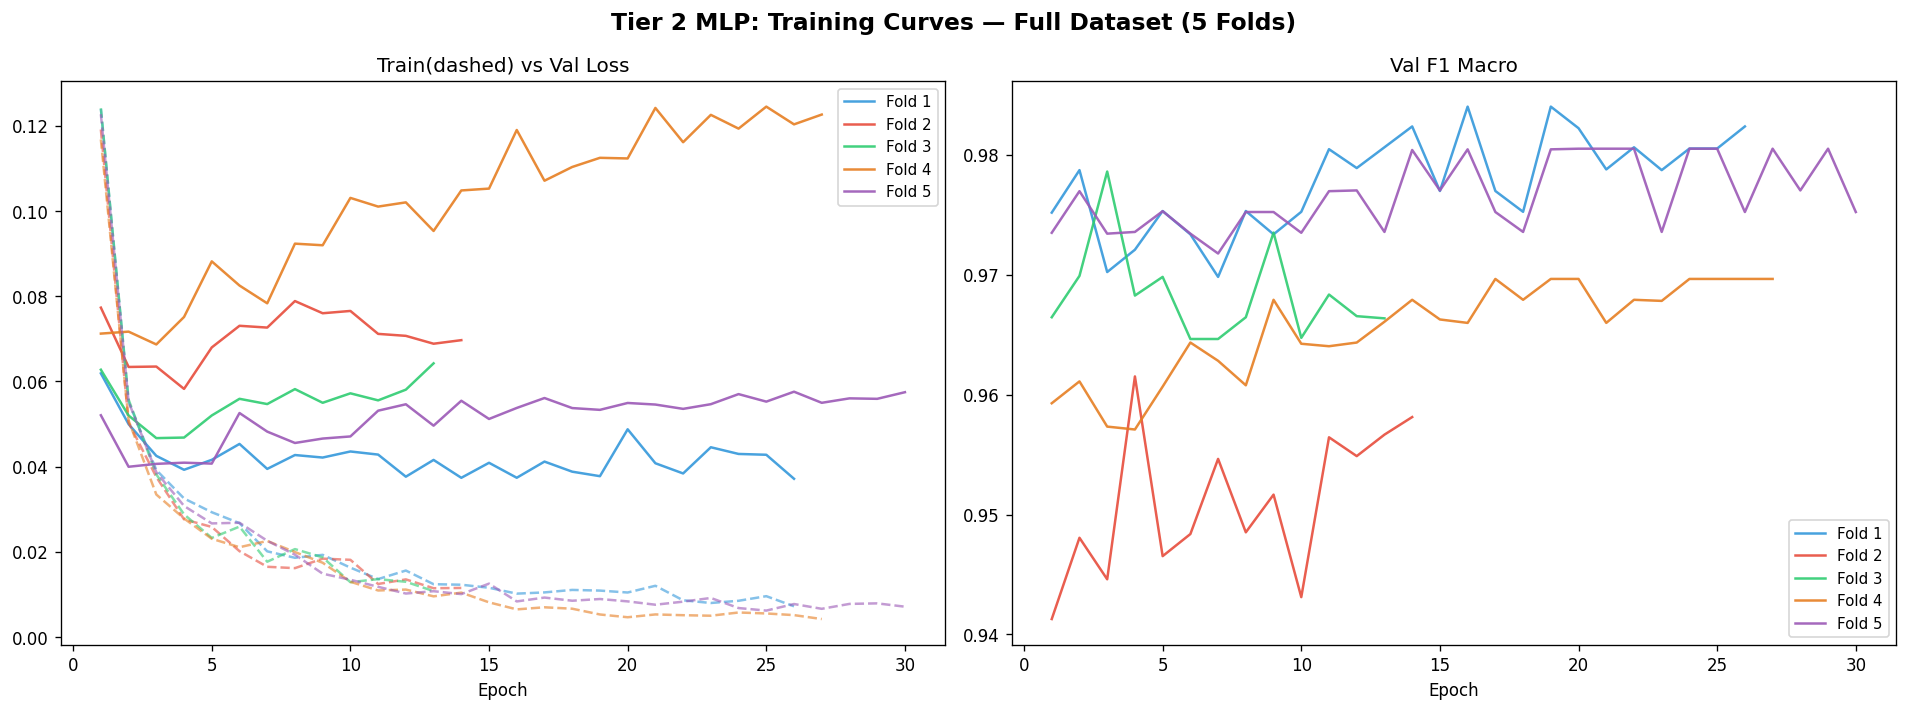

In [9]:
# VIZ 1: Training curves — Full 5 folds
fold_colors=['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6']
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 2 MLP: Training Curves — Full Dataset (5 Folds)',fontsize=14,fontweight='bold')
for fold,h in enumerate(hists_full):
    ep=range(1,len(h['train_loss'])+1)
    axes[0].plot(ep,h['train_loss'],'--',color=fold_colors[fold],alpha=0.6)
    axes[0].plot(ep,h['val_loss'],  '-', color=fold_colors[fold],alpha=0.9,label=f'Fold {fold+1}')
    axes[1].plot(ep,h['val_f1'],    '-', color=fold_colors[fold],alpha=0.9,label=f'Fold {fold+1}')
axes[0].set_title('Train(dashed) vs Val Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=9)
axes[1].set_title('Val F1 Macro'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('t2_plot_01_curves_full.png',bbox_inches='tight'); plt.show()

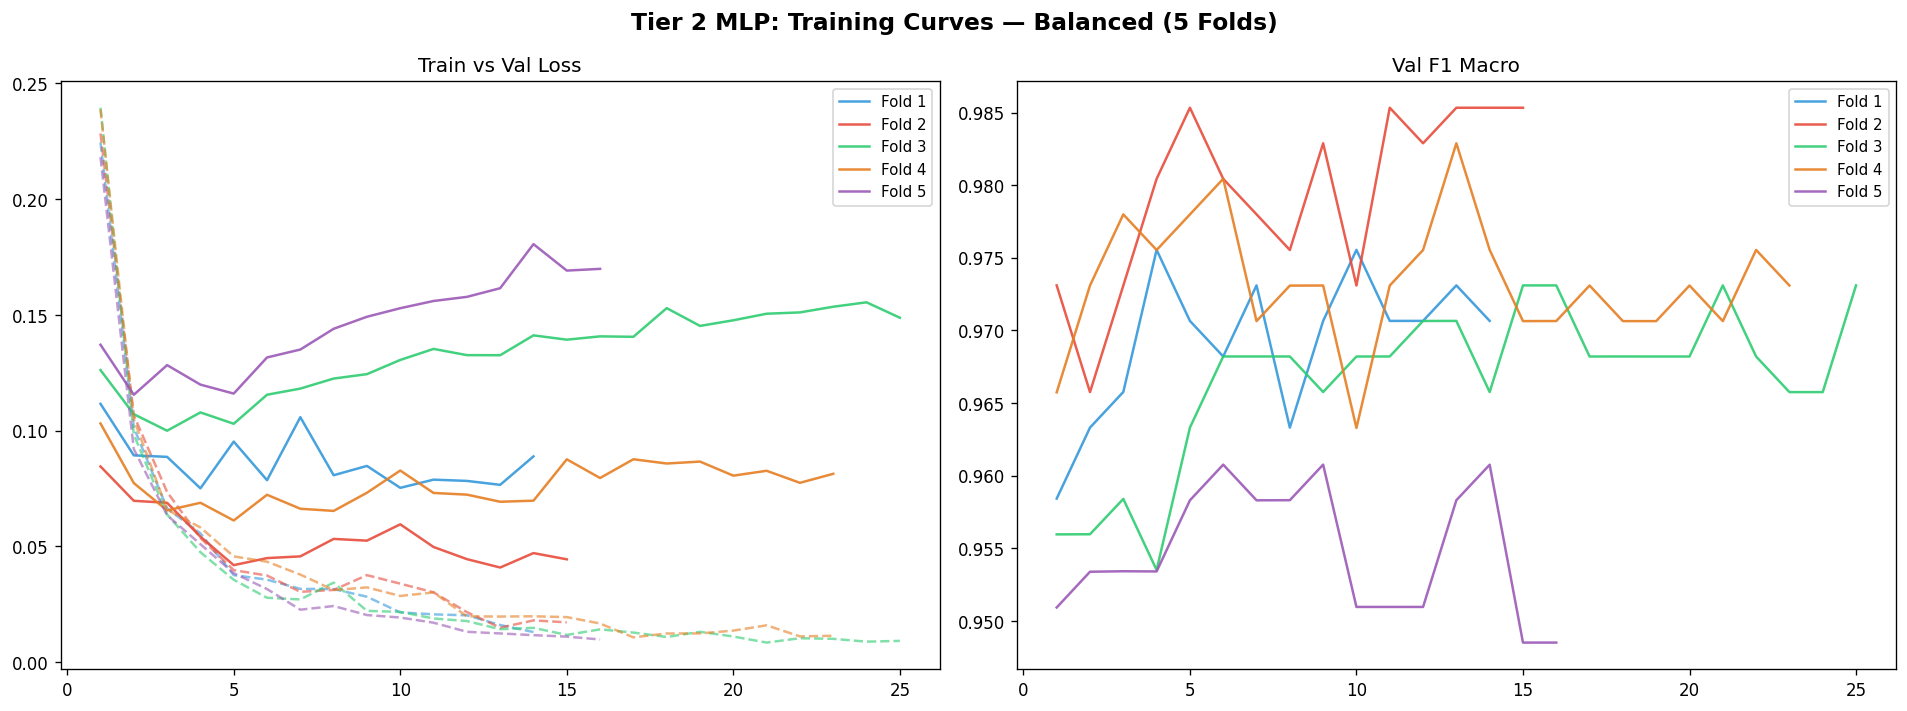

In [10]:
# VIZ 2: Training curves — Balanced
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Tier 2 MLP: Training Curves — Balanced (5 Folds)',fontsize=14,fontweight='bold')
for fold,h in enumerate(hists_bal):
    ep=range(1,len(h['train_loss'])+1)
    axes[0].plot(ep,h['train_loss'],'--',color=fold_colors[fold],alpha=0.6)
    axes[0].plot(ep,h['val_loss'],  '-', color=fold_colors[fold],alpha=0.9,label=f'Fold {fold+1}')
    axes[1].plot(ep,h['val_f1'],    '-', color=fold_colors[fold],alpha=0.9,label=f'Fold {fold+1}')
axes[0].set_title('Train vs Val Loss'); axes[0].legend(fontsize=9)
axes[1].set_title('Val F1 Macro');      axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('t2_plot_02_curves_bal.png',bbox_inches='tight'); plt.show()

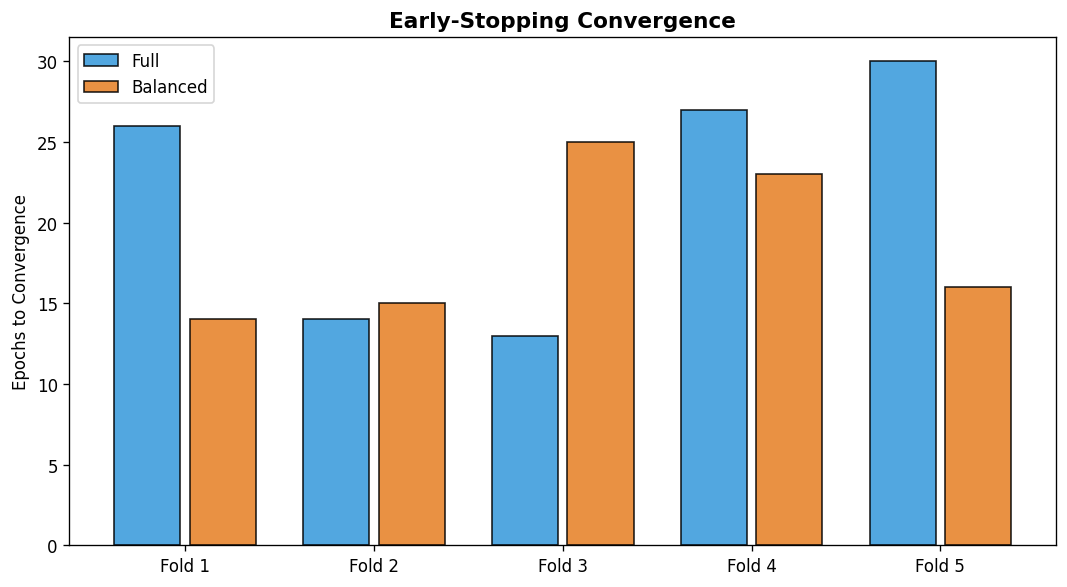

In [11]:
# VIZ 3: Epoch convergence
ep_f=[len(h['val_f1']) for h in hists_full]; ep_b=[len(h['val_f1']) for h in hists_bal]
fig,ax=plt.subplots(figsize=(9,5))
x=np.arange(5)
ax.bar(x-0.2,ep_f,0.35,label='Full',    color='#3498db',edgecolor='black',alpha=0.85)
ax.bar(x+0.2,ep_b,0.35,label='Balanced',color='#e67e22',edgecolor='black',alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('Epochs to Convergence'); ax.set_title('Early-Stopping Convergence',fontsize=13,fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('t2_plot_03_epoch_conv.png',bbox_inches='tight'); plt.show()

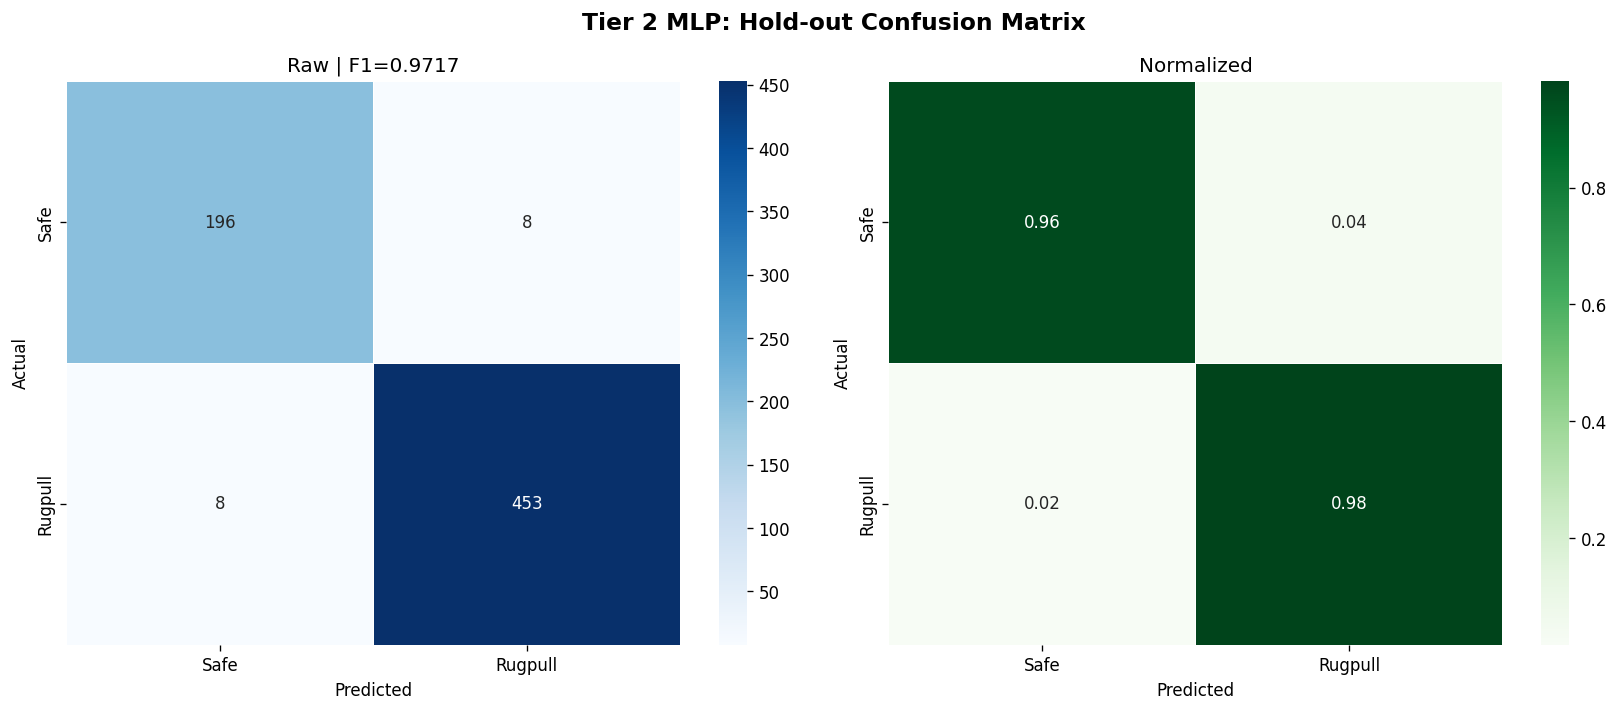

In [12]:
# VIZ 4: Confusion matrix (raw + normalized)
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier 2 MLP: Hold-out Confusion Matrix',fontsize=14,fontweight='bold')
cm=confusion_matrix(y_te,pred_te)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0],
            xticklabels=['Safe','Rugpull'],yticklabels=['Safe','Rugpull'],linewidths=0.5)
axes[0].set_title(f'Raw | F1={f1_score(y_te,pred_te,average="macro"):.4f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
cm_n=cm.astype(float)/cm.sum(axis=1)[:,None]
sns.heatmap(cm_n,annot=True,fmt='.2f',cmap='Greens',ax=axes[1],
            xticklabels=['Safe','Rugpull'],yticklabels=['Safe','Rugpull'],linewidths=0.5)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('t2_plot_04_confusion.png',bbox_inches='tight'); plt.show()

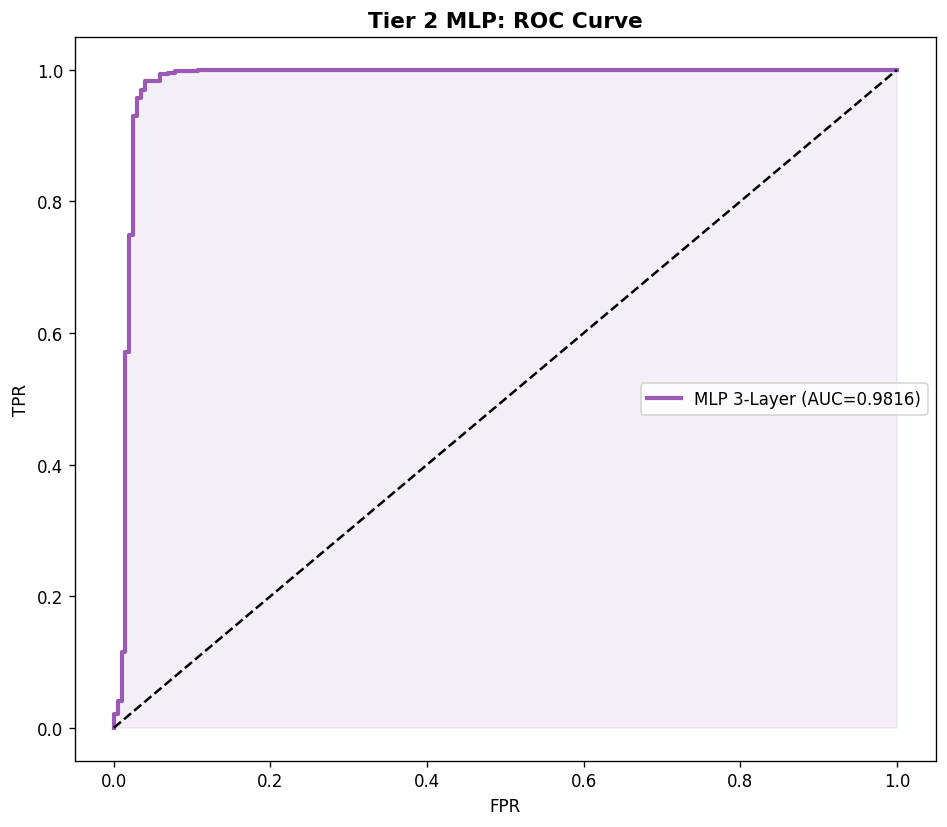

In [13]:
# VIZ 5: ROC Curve
fpr,tpr,_=roc_curve(y_te,prob_te); auc=roc_auc_score(y_te,prob_te)
fig,ax=plt.subplots(figsize=(8,7))
ax.plot(fpr,tpr,lw=2.5,color='#9b59b6',label=f'MLP 3-Layer (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--'); ax.fill_between(fpr,tpr,alpha=0.1,color='#9b59b6')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Tier 2 MLP: ROC Curve',fontsize=13,fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('t2_plot_05_roc.png',bbox_inches='tight'); plt.show()

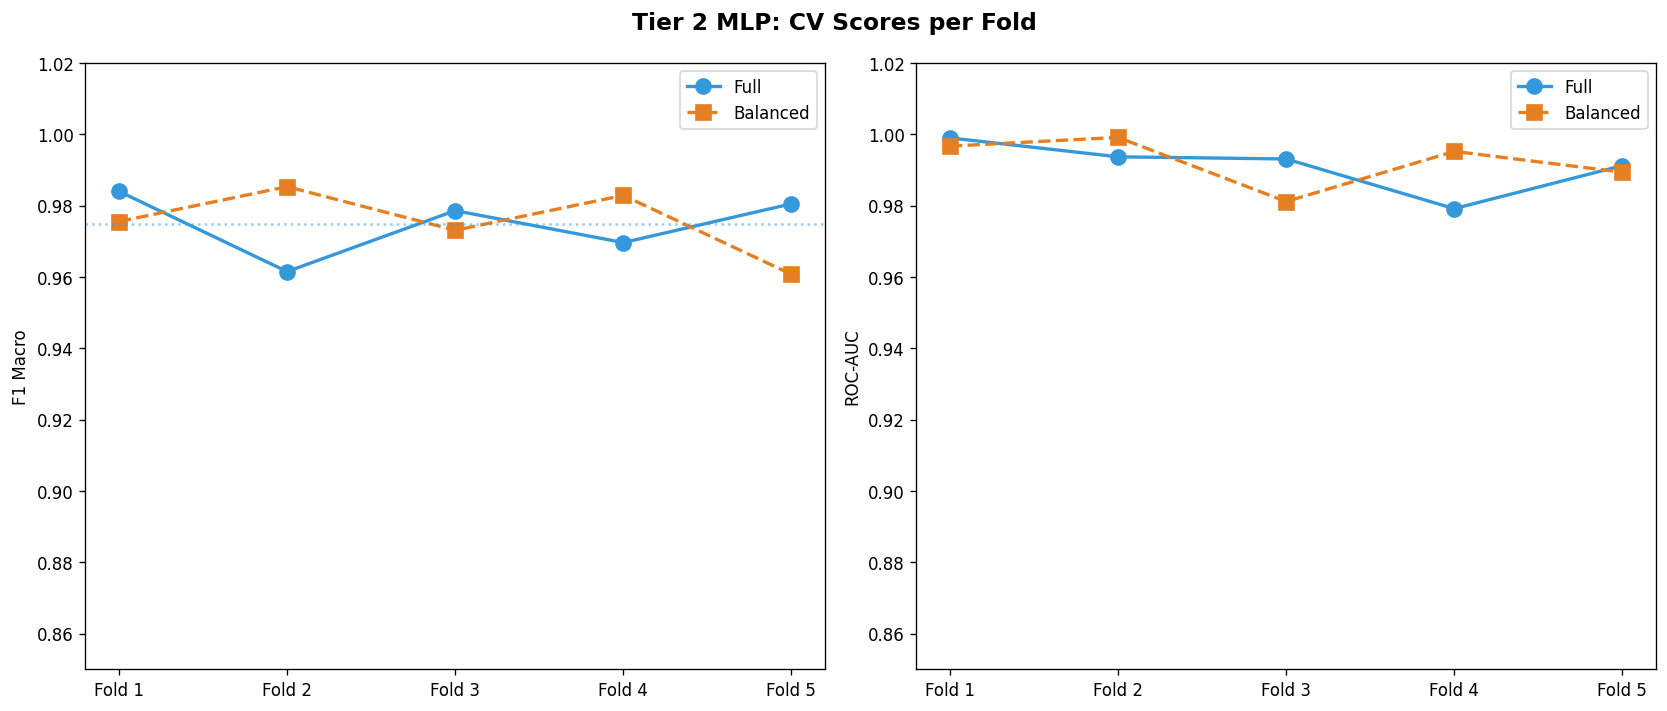

In [14]:
# VIZ 6: Per-fold F1 & AUC — Full vs Balanced
folds=[f'Fold {i+1}' for i in range(5)]
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier 2 MLP: CV Scores per Fold',fontsize=14,fontweight='bold')
axes[0].plot(folds,fold_f1_full,'o-',color='#3498db',lw=2,ms=9,label='Full')
axes[0].plot(folds,fold_f1_bal, 's--',color='#e67e22',lw=2,ms=9,label='Balanced')
axes[0].axhline(np.mean(fold_f1_full),color='#3498db',linestyle=':',alpha=0.5)
axes[0].set_ylabel('F1 Macro'); axes[0].legend(); axes[0].set_ylim(0.85,1.02)
axes[1].plot(folds,fold_auc_full,'o-',color='#3498db',lw=2,ms=9,label='Full')
axes[1].plot(folds,fold_auc_bal, 's--',color='#e67e22',lw=2,ms=9,label='Balanced')
axes[1].set_ylabel('ROC-AUC'); axes[1].legend(); axes[1].set_ylim(0.85,1.02)
plt.tight_layout()
plt.savefig('t2_plot_06_cv_folds.png',bbox_inches='tight'); plt.show()

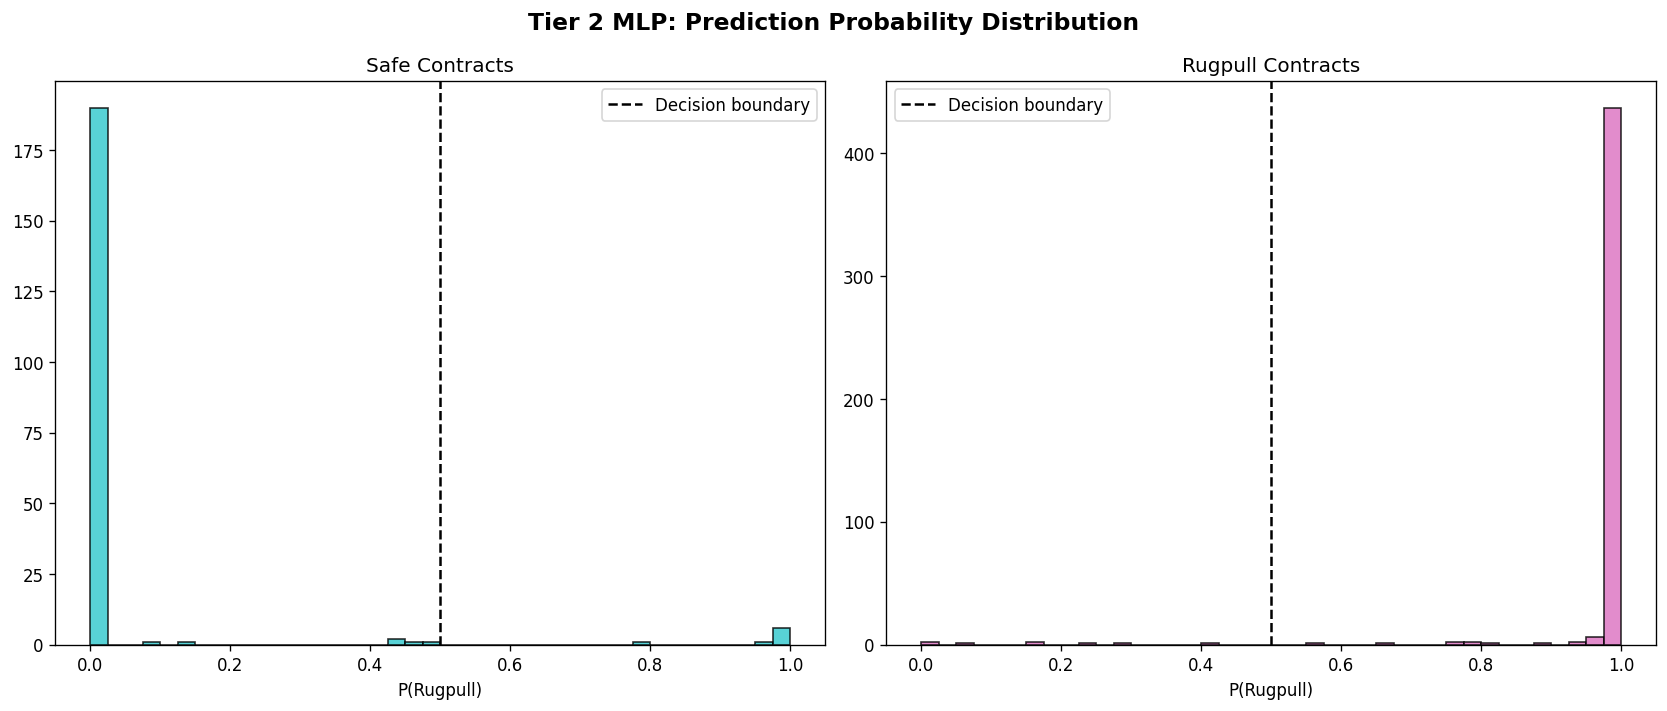

In [15]:
# VIZ 7: Prediction confidence distribution
fig,axes=plt.subplots(1,2,figsize=(14,6))
fig.suptitle('Tier 2 MLP: Prediction Probability Distribution',fontsize=14,fontweight='bold')
for ax,mask,title,color in [
    (axes[0],y_te==0,'Safe Contracts',COLORS[0]),
    (axes[1],y_te==1,'Rugpull Contracts',COLORS[1])
]:
    ax.hist(prob_te[mask],bins=40,color=color,edgecolor='black',alpha=0.8)
    ax.axvline(0.5,color='black',linestyle='--',label='Decision boundary')
    ax.set_xlabel('P(Rugpull)'); ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig('t2_plot_07_confidence.png',bbox_inches='tight'); plt.show()

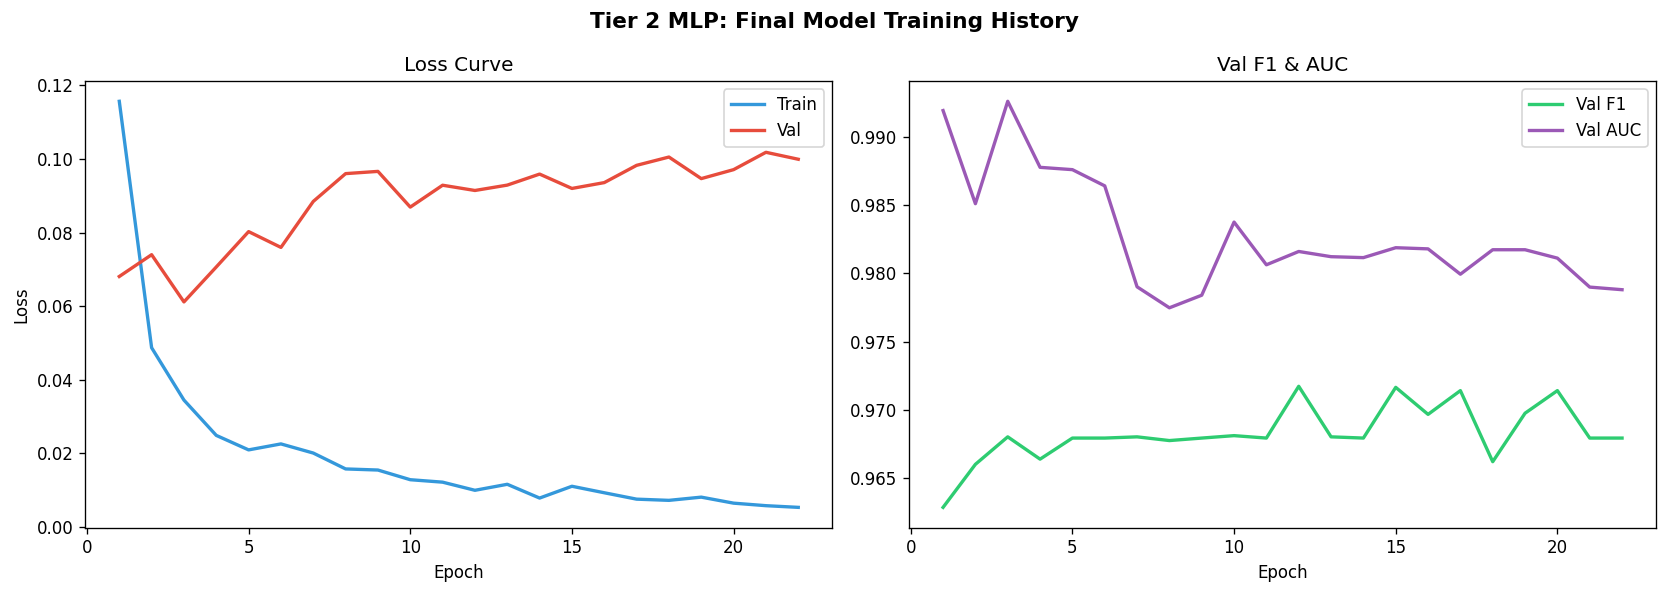

In [16]:
# VIZ 8: Train vs Val Loss (final model)
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Tier 2 MLP: Final Model Training History',fontsize=13,fontweight='bold')
ep=range(1,len(final_h['train_loss'])+1)
axes[0].plot(ep,final_h['train_loss'],color='#3498db',lw=2,label='Train')
axes[0].plot(ep,final_h['val_loss'],  color='#e74c3c',lw=2,label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('Loss Curve')
axes[1].plot(ep,final_h['val_f1'], color='#2ecc71',lw=2,label='Val F1')
axes[1].plot(ep,final_h['val_auc'],color='#9b59b6',lw=2,label='Val AUC')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].set_title('Val F1 & AUC')
plt.tight_layout()
plt.savefig('t2_plot_08_final_history.png',bbox_inches='tight'); plt.show()

In [17]:
tier2_raw={'MLP_3Layer':{
    'full_f1_mean':float(np.mean(fold_f1_full)),'full_f1_std':float(np.std(fold_f1_full)),
    'full_auc_mean':float(np.mean(fold_auc_full)),
    'bal_f1_mean':float(np.mean(fold_f1_bal)),'bal_auc_mean':float(np.mean(fold_auc_bal)),
    'holdout_f1':float(f1_score(y_te,pred_te,average='macro')),
    'holdout_auc':float(roc_auc_score(y_te,prob_te))
}}
with open('tier2_raw_results.json','w') as f: json.dump(tier2_raw,f,indent=2)
torch.save(final_m.state_dict(),'mlp3_best_model.pt')
print('Saved: tier2_raw_results.json | mlp3_best_model.pt')
print('=== TIER 2 COMPLETE ===')

Saved: tier2_raw_results.json | mlp3_best_model.pt
=== TIER 2 COMPLETE ===
